<div style="
  background: linear-gradient(145deg, #1a0b08, #2d1310);
  border: 4px solid transparent;
  border-radius: 14px;
  padding: 20px 24px;
  margin: 12px 0;
  font-size: 26px;
  font-weight: 600;
  color: #fff8f6;
  box-shadow: 0 6px 14px rgba(0,0,0,0.3);
  background-clip: padding-box;
  position: relative;
">
  <div style="
    position: absolute;
    inset: 0;
    padding: 4px;
    border-radius: 14px;
    background: linear-gradient(90deg, #ff7b00, #ff0054, #9d0208);
    -webkit-mask:
      linear-gradient(#fff 0 0) content-box,
      linear-gradient(#fff 0 0);
    -webkit-mask-composite: xor;
    mask-composite: exclude;
    pointer-events: none;
  "></div>
  
  <b>06 $\rightarrow$ Sentiment Analysis with Deep Learning using BERT</b>
  <br>
  <span style="color:#ffb5a7; font-size: 18px;">(Fine-Tuning BERT with PyTorch & Hugging Face Transformers for Multi-Class Emotion Classification)</span>
</div>


---

# Table of Contents

1. [Introduction to BERT & Transformer Architecture](#1-introduction)
   - 1.1 [What is BERT?](#11-what-is-bert)
   - 1.2 [BERT Embeddings Architecture](#12-bert-embeddings)
   - 1.3 [Model Architecture Deep-Dive](#13-model-architecture)
   - 1.4 [Transformer Model Architecture](#14-transformer-model)
     - 1.4.1 [Multi-Head Attention](#141-multi-head-attention)
2. [Exploratory Data Analysis and Preprocessing](#2-exploratory-data-analysis-and-preprocessing)
   - 2.1 [SMILE Twitter Dataset Loading](#21-smile-twitter-dataset)
   - 2.2 [Index Assignment & Data Cleaning](#22-index-assignment)
   - 2.3 [Class Imbalance Analysis](#23-class-imbalance)
   - 2.4 [Visual Exploratory Data Analysis (Class & Length Distributions)](#24-visual-eda)
   - 2.5 [Label Encoding Dictionary](#25-label-encoding)
3. [Training/Validation Split](#3-training-validation-split)
   - 3.1 [Stratified Train/Val Partitioning](#31-stratified-split)
   - 3.2 [Verifying Class Proportions Across Splits](#32-verifying-class-proportions)
   - 3.3 [Visual Verification of Stratified Split](#33-visual-split-verification)
4. [Loading Tokenizer and Encoding our Data](#4-loading-tokenizer-and-encoding-data)
   - 4.1 [BERT Tokenizer & WordPiece Tokenization](#41-bert-tokenizer)
   - 4.2 [Batch Encoding with Attention Masks](#42-batch-encoding)
   - 4.3 [TensorDataset Creation for PyTorch](#43-tensor-dataset)
5. [Setting up BERT Pretrained Model](#5-setting-up-bert-pretrained-model)
   - 5.1 [BertForSequenceClassification Initialization](#51-bert-model-initialization)
6. [Creating Data Loaders](#6-creating-data-loaders)
   - 6.1 [PyTorch DataLoader with Random & Sequential Samplers](#61-dataloader-samplers)
7. [Setting Up Optimizer and Scheduler](#7-setting-up-optimizer-and-scheduler)
   - 7.1 [AdamW Optimizer Configuration](#71-adamw-optimizer)
   - 7.2 [Linear Learning Rate Scheduler with Warmup](#72-linear-scheduler)
8. [Defining our Performance Metrics](#8-defining-performance-metrics)
   - 8.1 [F1 Score & Tensor Flattening](#81-f1-score)
   - 8.2 [Per-Class Accuracy Metric](#82-accuracy-per-class)
9. [Training and Validation Loop](#9-training-and-validation-loop)
   - 9.1 [Reproducibility & Random Seed Configuration](#91-reproducibility-seed)
   - 9.2 [PyTorch Fine-Tuning Execution with Gradient Clipping](#92-fine-tuning-loop)
   - 9.3 [Training & Validation Loss Learning Curves](#93-learning-curves)
10. [Model Evaluation & Performance Assessment](#10-model-evaluation-assessment)
    - 10.1 [Per-Class Accuracy Evaluation on Validation Set](#101-per-class-accuracy)
    - 10.2 [Confusion Matrix Heatmap Analysis](#102-confusion-matrix-heatmap)
    - 10.3 [Per-Class Classification Report & Metrics Visualization](#103-metrics-visualization)
11. [Key References & Resources](#11-references-and-resources)

---


<a id="1-introduction"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">1. Introduction to BERT & Transformer Architecture</span>

<a id="11-what-is-bert"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">1.1 What is BERT?</span>

**Bidirectional Encoder Representations from Transformers (BERT)**

<div align="center" style="margin: 18px 0;">
  <img src="assets/bert.png" style="border-radius: 10px; box-shadow: 0 4px 14px rgba(0,0,0,0.15); max-width: 85%; height: auto;" alt="BERT Architecture Overview">
</div>

- **BERT** represents a paradigm shift from traditional recurrent neural networks (**RNNs** / LSTMs). Because transformers use pure attention mechanisms rather than sequential recurrence, BERT can process and train on entire sequences in **parallel** rather than step-by-step.
- **BERT** is a large-scale transformer-based language representation model pre-trained on massive corpora (Wikipedia + BooksCorpus) that can be fine-tuned with just one additional output layer for a wide range of downstream NLP tasks.


> **Hugging Face Transformers**: We utilize the **Hugging Face Transformers library**, which provides unified, high-level PyTorch APIs to state-of-the-art transformer architectures including **BERT, RoBERTa, DistilBERT, ALBERT, and GPT-2**. We also leverage their high-performance **Tokenizers** library for fast sub-word encoding.


### Key Specifications

- **Bidirectional**: Unlike causal models that read strictly left-to-right (e.g. GPT), BERT conditions jointly on both left and right context across all layers.
- **Generalizable**: A pre-trained BERT checkpoint can be adapted to text classification, question answering, NER, and sentiment analysis with minimal fine-tuning.
- **High Performance**: Fine-tuned BERT established new state-of-the-art results across 11 NLP benchmarks upon release.
- **Universal Pre-training**: Pre-trained on BooksCorpus (800M words) and English Wikipedia (2,500M words) with masked language modeling (MLM) and next sentence prediction (NSP).


| Architectural Extensions | Multilingual & Domain Variants |
|:---|:---|
| • **RoBERTa** (Optimized pre-training) | • **CamemBERT** (French) |
| • **DistilBERT** (Lightweight, 60% faster) | • **AraBERT** (Arabic) |
| • **ALBERT** (Parameter-efficient) | • **mBERT** (104 Languages Multilingual) |


Google Research open-sourced the following primary pre-trained BERT checkpoints:

| Checkpoint | Layers ($L$) | Hidden Size ($H$) | Attention Heads ($A$) | Parameters | Description |
|:---|:---:|:---:|:---:|:---:|:---|
| **BERT-Base, Uncased** | 12 | 768 | 12 | 110M | Lowercase text; standard baseline (used in this project) |
| **BERT-Large, Uncased** | 24 | 1024 | 16 | 340M | High-capacity model for complex linguistic tasks |
| **BERT-Base, Cased** | 12 | 768 | 12 | 110M | Case-sensitive; suitable for NER and sentiment nuances |
| **BERT-Large, Cased** | 24 | 1024 | 16 | 340M | Case-sensitive large checkpoint |
| **BERT-Base, Multilingual** | 12 | 768 | 12 | 110M | Trained across 104 languages simultaneously |


<a id="12-bert-embeddings"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">1.2 BERT Embeddings Architecture</span>


In BERT, the input representation for each token is constructed by summing three distinct embeddings:

<div align="center" style="margin: 18px 0;">
  <img src="assets/bert_embeddings.jpg" style="border-radius: 10px; box-shadow: 0 4px 14px rgba(0,0,0,0.15); max-width: 90%; height: auto;" alt="BERT Embeddings">
</div>

1. **Token Embeddings**: Standard word/sub-word vector representations using WordPiece. The sequence begins with the special classification token `[CLS]` and pairs are separated by `[SEP]`.
2. **Segment Embeddings**: Distinguishes between sentence pairs ($E_A$ vs $E_B$) in pair-classification and question-answering tasks.
3. **Position Embeddings**: Learned positional representations added to encode word sequence order, as attention operations are inherently permutation invariant.


<a id="13-model-architecture"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">1.3 Model Architecture Deep-Dive</span>


BERT's structural breakdown for sequence classification:

- **BertEmbeddings**: Input token, position, and token-type embedding lookup layers with LayerNorm and Dropout.
- **BertEncoder**: Stack of 12 identical transformer encoder layers (BertLayer), each containing multi-head self-attention, intermediate feed-forward projections, and residual LayerNorm.
- **BertPooler**: Extracts the hidden state corresponding to the first token (`[CLS]`), passed through a Linear layer with Tanh activation.
- **Classifier**: A task-specific linear projection layer mapping hidden dimension (768) to number of target classes (6 in our project).

```python
BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12)
      (dropout): Dropout(p=0.1)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(query, key, value, 12 heads)
            (output): BertSelfOutput(dense, LayerNorm, dropout)
          )
          (intermediate): BertIntermediate(dense: 768 -> 3072, gelu)
          (output): BertOutput(dense: 3072 -> 768, LayerNorm, dropout)
        )
      )
    )
    (pooler): BertPooler(dense: 768 -> 768, activation: Tanh)
  )
  (dropout): Dropout(p=0.1)
  (classifier): Linear(in_features=768, out_features=num_labels)
)
```


<a id="14-transformer-model"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">1.4 The Transformer Model</span>


The Transformer architecture was introduced in *Attention Is All You Need* (Vaswani et al., 2017). By replacing sequential recurrence with self-attention mechanisms, Transformers model dependencies between words regardless of their distance in the input sequence, with constant $O(1)$ path length.

<div align="center" style="margin: 18px 0;">
  <img src="assets/transformer_model.png" style="border-radius: 10px; box-shadow: 0 4px 14px rgba(0,0,0,0.15); max-width: 80%; height: auto;" alt="Transformer Architecture">
</div>

<a id="141-multi-head-attention"></a>
#### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #2563EB, #1D4ED8); padding: 5px 14px; border-radius: 5px; font-size: 14px; font-weight: 600; letter-spacing: 0.2px;">1.4.1 Multi-Head Attention</span>


Rather than computing a single attention function, Multi-Head Attention linearly projects Queries ($Q$), Keys ($K$), and Values ($V$) $h$ times with different learned parameter matrices, performing scaled dot-product attention in parallel across subspaces:

<div align="center" style="margin: 18px 0;">
  <img src="assets/multi_head_attention.png" style="border-radius: 10px; box-shadow: 0 4px 14px rgba(0,0,0,0.15); max-width: 80%; height: auto;" alt="Multi-Head Attention Mechanism">
</div>

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

$$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h)W^O$$

$$\text{where } \text{head}_i = \text{Attention}(QW_i^Q, KW_i^K, VW_i^V)$$


<a id="2-exploratory-data-analysis-and-preprocessing"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">2. Exploratory Data Analysis and Preprocessing</span>

<a id="21-smile-twitter-dataset"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">2.1 SMILE Twitter Emotion Dataset Loading</span>


We utilize the **SMILE (Social Media In Low-resource Environments) Twitter Emotion Dataset**, an annotated collection of tweets mapped to human emotional states.

> **Citation**: *Wang, Bo; Tsakalidis, Adam; Liakata, Maria; Zubiaga, Arkaitz; Procter, Rob; Jensen, Eric (2016): SMILE Twitter Emotion dataset. figshare. Dataset.* [https://doi.org/10.6084/m9.figshare.3187909.v2](https://doi.org/10.6084/m9.figshare.3187909.v2)


> **Progress Tracking with tqdm**: The `tqdm` library provides customizable, low-overhead progress bars for Python iterables, giving real-time feedback on batch throughput, elapsed time, and ETA during tokenization and training loops. [Video Tutorial](https://youtu.be/qVHM3ly-Amg)


In [4]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from tqdm.notebook import tqdm

# Styling settings
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

In [5]:
!wget

wget: missing URL
Usage: wget [OPTION]... [URL]...

Try `wget --help' for more options.


In [6]:
# Load dataset directly from data/ folder
df = pd.read_csv('data/smile-annotations-final.csv', names=['id', 'text', 'category'])
df.set_index('id', inplace=True)
print(f'Total samples loaded: {len(df):,}')
df.head()

Total samples loaded: 3,085


,text,category
id,,
611857364396965889,@aandraous @britishmuseum @AndrewsAntonio Merc...,nocode
614484565059596288,Dorian Gray with Rainbow Scarf #LoveWins (from...,happy
614746522043973632,@SelectShowcase @Tate_StIves ... Replace with ...,happy
614877582664835073,@Sofabsports thank you for following me back. ...,happy
611932373039644672,@britishmuseum @TudorHistory What a beautiful ...,happy


<a id="22-index-assignment"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">2.2 Index Assignment & Data Cleaning</span>


Pandas `set_index()` sets an existing column (such as the tweet `id`) as the DataFrame index. Setting a unique index ensures reliable sample tracking throughout train/validation partitioning.

```python
DataFrame.set_index(keys, drop=True, append=False, inplace=False, verify_integrity=False)
```


In [7]:
df.text.iloc[1]

'Dorian Gray with Rainbow Scarf #LoveWins (from @britishmuseum http://t.co/Q4XSwL0esu) http://t.co/h0evbTBWRq'

In [8]:
df.head(10)

,text,category
id,,
611857364396965889,@aandraous @britishmuseum @AndrewsAntonio Merc...,nocode
614484565059596288,Dorian Gray with Rainbow Scarf #LoveWins (from...,happy
614746522043973632,@SelectShowcase @Tate_StIves ... Replace with ...,happy
614877582664835073,@Sofabsports thank you for following me back. ...,happy
611932373039644672,@britishmuseum @TudorHistory What a beautiful ...,happy
611570404268883969,@NationalGallery @ThePoldarkian I have always ...,happy
614456889863208960,"@britishmuseum say wot, mate?",nocode
614016385442807809,Two workshops on evaluating audience engagemen...,nocode
610916556751642624,"A Forest Road, by Thomas Gainsborough 1750 Oil...",nocode


> **Note**: The `id` column is bolded in the table preview because it has been designated as the DataFrame index, serving as a unique row identifier rather than a data feature column.


In [9]:
df.category.value_counts()


,count
category,
nocode,1572
happy,1137
not-relevant,214
angry,57
surprise,35
sad,32
happy|surprise,11
happy|sad,9
disgust|angry,7


### Data Cleaning Decisions:

1. **Exclude nocode samples**: Entries labeled `nocode` contain unannotated or ambiguous text devoid of identifiable emotional sentiment.
2. **Exclude multiple/compound emotions**: Samples containing the pipe character `|` (e.g. `happy|surprise`) are removed to frame the task as single-label multi-class classification.
3. **Single Output per Tweet**: Each tweet is guaranteed to map unambiguously to exactly one primary emotion category.


In [10]:
# Removing tweets with multiple categories (pipe character) and unannotated nocode
df = df[~df.category.str.contains(r'\|', regex=True)]
df = df[df.category != 'nocode']
print(f'Remaining cleaned samples: {len(df)}')


Remaining cleaned samples: 1481


In [11]:
df.category.value_counts()


,count
category,
happy,1137
not-relevant,214
angry,57
surprise,35
sad,32
disgust,6


<a id="23-class-imbalance"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">2.3 Class Imbalance Analysis</span>


Inspection of class distribution reveals a pronounced **class imbalance** in the dataset:

| Category | Sample Count | Percentage |
|:---|:---:|:---:|
| **happy** | 1,137 | ~76.8% |
| **not-relevant** | 214 | ~14.5% |
| **angry** | 57 | ~3.8% |
| **surprise** | 35 | ~2.4% |
| **sad** | 32 | ~2.2% |
| **disgust** | 6 | ~0.4% |

> **Imbalance Strategy**: Stratified splitting is required to ensure that each partition (train and validation) preserves this exact proportion of classes.


<a id="24-visual-eda"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">2.4 Visual Exploratory Data Analysis (Class & Length Distributions)</span>


We visualize the severe class skew across emotion categories alongside the sequence length distribution of tweets to justify BERT's maximum sequence length selection (`max_length = 256`).


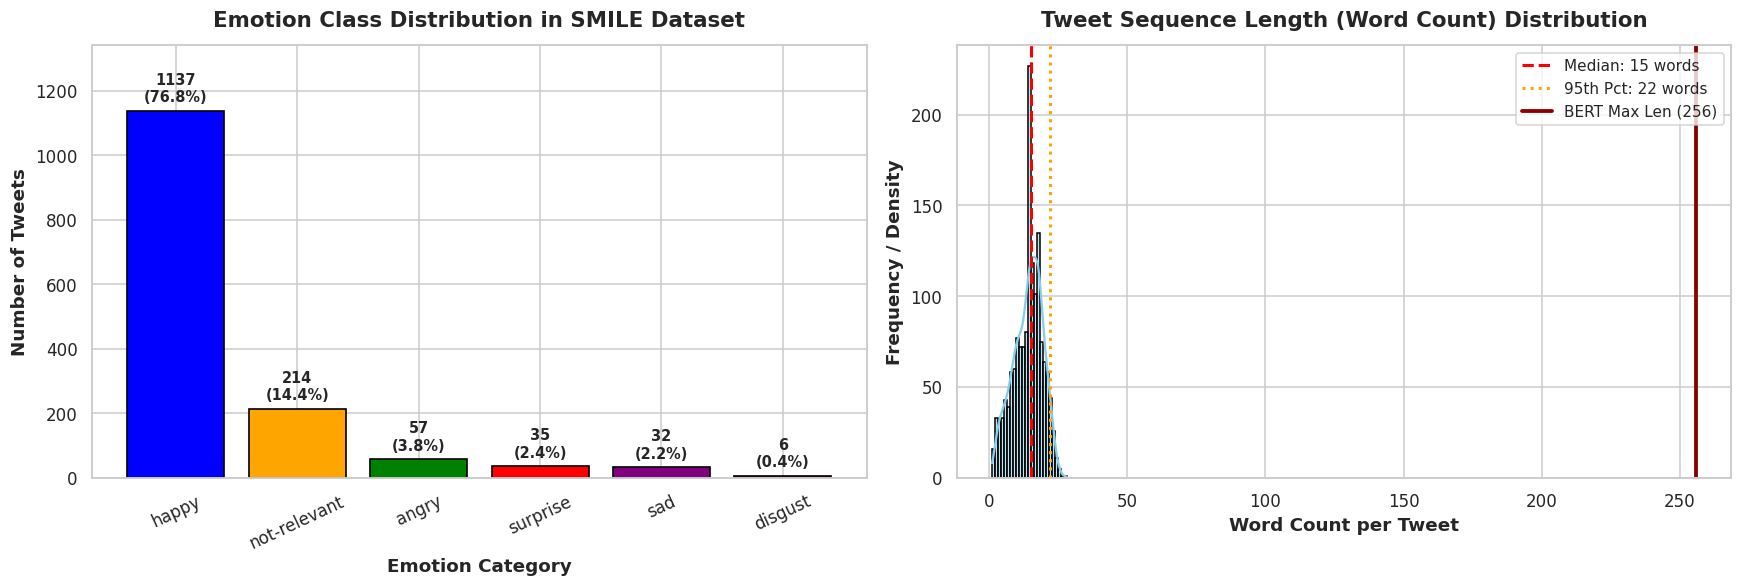

In [12]:
# ======================================================================
# Visual Exploratory Data Analysis: Class Skew & Sequence Length
# ======================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# 1. Emotion Class Distribution with Counts & Percentages
counts = df['category'].value_counts()
total = len(df)
colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown']

ax1 = axes[0]
bars = ax1.bar(counts.index, counts.values, color=colors, edgecolor='black', linewidth=1.1)
ax1.set_title('Emotion Class Distribution in SMILE Dataset', fontsize=14, fontweight='bold', pad=12)
ax1.set_xlabel('Emotion Category', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Tweets', fontsize=12, fontweight='bold')
ax1.tick_params(axis='x', rotation=25)
ax1.set_ylim(0, max(counts.values) * 1.18)

for bar in bars:
    h = bar.get_height()
    pct = (h / total) * 100
    ax1.annotate(f'{h}\n({pct:.1f}%)',
                 xy=(bar.get_x() + bar.get_width() / 2, h),
                 xytext=(0, 4), textcoords='offset points',
                 ha='center', va='bottom', fontsize=9.5, fontweight='bold')

# 2. Word Count Distribution & BERT Max Length Benchmark
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
median_len = df['word_count'].median()
p95_len = df['word_count'].quantile(0.95)

ax2 = axes[1]
sns.histplot(df['word_count'], bins=25, kde=True, color='skyblue', edgecolor='black', ax=ax2)
ax2.axvline(median_len, color='red', linestyle='--', linewidth=2, label=f'Median: {int(median_len)} words')
ax2.axvline(p95_len, color='orange', linestyle=':', linewidth=2, label=f'95th Pct: {int(p95_len)} words')
ax2.axvline(256, color='darkred', linestyle='-', linewidth=2.5, label='BERT Max Len (256)')
ax2.set_title('Tweet Sequence Length (Word Count) Distribution', fontsize=14, fontweight='bold', pad=12)
ax2.set_xlabel('Word Count per Tweet', fontsize=12, fontweight='bold')
ax2.set_ylabel('Frequency / Density', fontsize=12, fontweight='bold')
ax2.legend(loc='upper right', frameon=True, fontsize=10)

plt.tight_layout()
plt.show()


<a id="25-label-encoding"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">2.5 Label Encoding Dictionary</span>


We construct a mapping dictionary to convert textual emotion categories into numerical integer indices ($0$ to $5$) for model compatibility.


In [13]:
possible_labels = df.category.unique()


In [14]:
label_dict = {}
for index, possible_label in enumerate(possible_labels):
    label_dict[possible_label] = index
label_dict


{'happy': 0,
 'not-relevant': 1,
 'angry': 2,
 'disgust': 3,
 'sad': 4,
 'surprise': 5}

> **Python enumerate() Function**: The built-in `enumerate(iterable, start=0)` function adds an automatic counter to an iterable, yielding pairs of `(index, value)`. This cleanly associates sequential integer IDs with each unique emotion category.


In [15]:
# Encode categorical emotion labels to numerical targets
df['label'] = df['category'].map(label_dict)
df.head(10)


,text,category,word_count,label
id,,,,
614484565059596288,Dorian Gray with Rainbow Scarf #LoveWins (from...,happy,10,0
614746522043973632,@SelectShowcase @Tate_StIves ... Replace with ...,happy,17,0
614877582664835073,@Sofabsports thank you for following me back. ...,happy,18,0
611932373039644672,@britishmuseum @TudorHistory What a beautiful ...,happy,14,0
611570404268883969,@NationalGallery @ThePoldarkian I have always ...,happy,8,0
614499696015503361,Lucky @FitzMuseum_UK! Good luck @MirandaStearn...,happy,12,0
613601881441570816,Yr 9 art students are off to the @britishmuseu...,happy,11,0
613696526297210880,@RAMMuseum Please vote for us as @sainsbury #s...,not-relevant,13,1
610746718641102848,#AskTheGallery Have you got plans to privatise...,not-relevant,12,1


<a id="3-training-validation-split"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">3. Training/Validation Split</span>

<a id="31-stratified-split"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">3.1 Stratified Train/Val Partitioning</span>


We partition our dataset into **85% training** and **15% validation** using Scikit-Learn's `train_test_split` with **stratification** enabled.


In [16]:
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(
    df.index.values,
    df.label.values,
    test_size=0.15,
    random_state=17,
    stratify=df.label.values
)


### Key Partitioning Parameters:

- `df.index.values`: Passing DataFrame indices preserves direct alignment with row identifiers.
- `test_size=0.15`: Allocates 15% to validation, reserving 85% for fine-tuning.
- `random_state=17`: Pins the random number generator seed to ensure identical splits across repeated runs.
- `stratify=df.label.values`: Crucial for imbalanced data — forces both training and validation sets to maintain identical class ratios.


In [17]:
# Designate split partitions in dataframe
df['data_type'] = ['not_set']*df.shape[0]
df.loc[x_train, 'data_type'] = 'train'
df.loc[x_val, 'data_type'] = 'val'
df.groupby(['category', 'label', 'data_type']).count()


text  word_count
category     label data_type                  
angry        2     train        48          48
                   val           9           9
disgust      3     train         5           5
                   val           1           1
happy        0     train       966         966
                   val         171         171
not-relevant 1     train       182         182
                   val          32          32
sad          4     train        27          27
                   val           5           5
surprise     5     train        30          30
                   val           5           5

<a id="32-verifying-class-proportions"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">3.2 Verifying Class Proportions Across Splits</span>


Using `df.groupby(['category', 'label', 'data_type']).count()`, we confirm that stratified partitioning accurately preserved the proportional distribution across both `train` and `val` splits.


<a id="33-visual-split-verification"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">3.3 Visual Verification of Stratified Split</span>


Side-by-side verification confirming that training (85%) and validation (15%) partitions maintain identical class ratios across all 6 emotion categories.


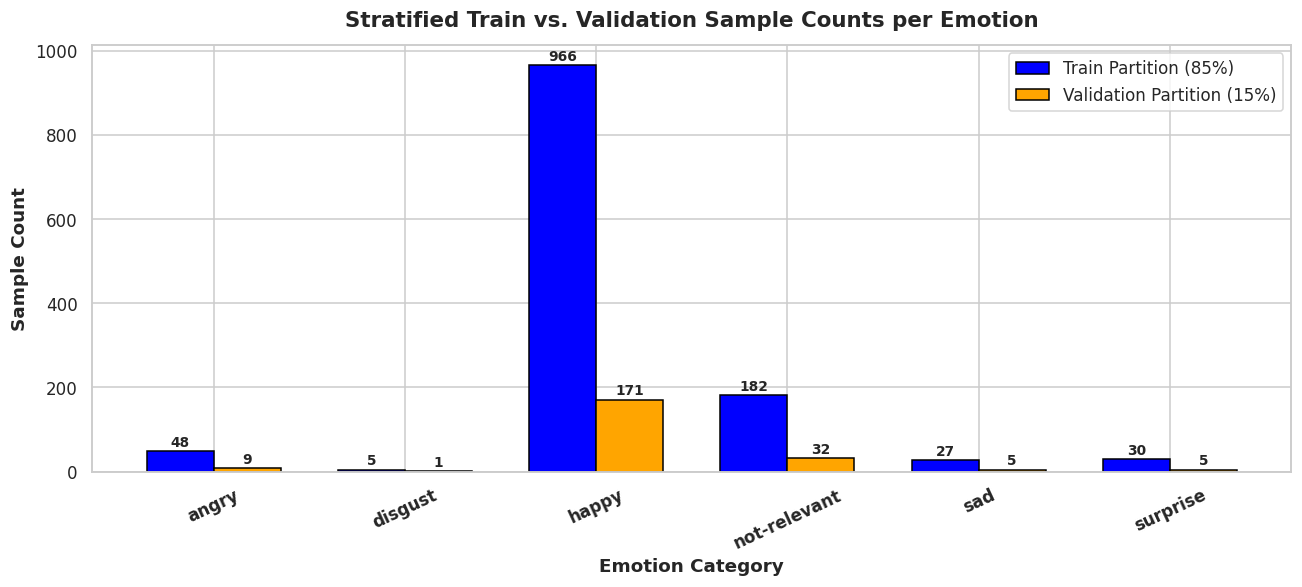

In [18]:
# ======================================================================
# Visual Verification: Stratified Split Proportions
# ======================================================================
split_counts = df.groupby(['category', 'data_type']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 5.5))
x = np.arange(len(split_counts.index))
width = 0.35

bars_train = ax.bar(x - width/2, split_counts['train'], width, label='Train Partition (85%)', color='blue', edgecolor='black')
bars_val = ax.bar(x + width/2, split_counts['val'], width, label='Validation Partition (15%)', color='orange', edgecolor='black')

ax.set_title('Stratified Train vs. Validation Sample Counts per Emotion', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Emotion Category', fontsize=12, fontweight='bold')
ax.set_ylabel('Sample Count', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(split_counts.index, rotation=25, fontsize=11, fontweight='bold')
ax.legend(frameon=True, fontsize=11)

for i, cat in enumerate(split_counts.index):
    t_count = split_counts.loc[cat, 'train']
    v_count = split_counts.loc[cat, 'val']
    ax.annotate(f'{t_count}', (x[i] - width/2, t_count), textcoords='offset points', xytext=(0, 3), ha='center', fontsize=9, fontweight='bold')
    ax.annotate(f'{v_count}', (x[i] + width/2, v_count), textcoords='offset points', xytext=(0, 3), ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


<a id="4-loading-tokenizer-and-encoding-data"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">4. Loading Tokenizer and Encoding our Data</span>

**BERT-Base, Uncased** uses a fixed vocabulary of **30,522 tokens**. To represent out-of-vocabulary (OOV) words and complex morphological variations, BERT uses **WordPiece tokenization**, recursively splitting unseen words into frequent sub-words prefixed with `##`.


In [19]:
from transformers import BertTokenizer
from torch.utils.data import TensorDataset

<a id="41-bert-tokenizer"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">4.1 BERT Tokenizer & WordPiece Tokenization</span>


The tokenizer parses raw natural language text into numerical token IDs matching the pre-trained model vocabulary.


> **WordPiece Tokenization Example**: When tokenizing the sentence *"Hi, my name is Dima"*, the tokenizer produces:
> `tokenizer.tokenize("Hi my name is Dima")` $\rightarrow$ `['hi', 'my', 'name', 'is', 'dim', '##a']`
> Sub-word token `##a` indicates a suffix continuation of the preceding token `dim`.


In [20]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased', do_lower_case=True)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

<a id="42-batch-encoding"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">4.2 Batch Encoding with Attention Masks</span>


We convert all training and validation tweet texts into padded and truncated token sequences with associated attention masks.


In [21]:
# Encoding training and validation data with modern HuggingFace parameters
encoded_data_train = tokenizer(
    df[df.data_type == 'train'].text.tolist(),
    add_special_tokens=True,
    return_attention_mask=True,
    padding='max_length',
    truncation=True,
    max_length=256,
    return_tensors='pt'
)

encoded_data_val = tokenizer(
    df[df.data_type == 'val'].text.tolist(),
    add_special_tokens=True,
    return_attention_mask=True,
    padding='max_length',
    truncation=True,
    max_length=256,
    return_tensors='pt'
)


### Batch Encoding Configuration:

- `tokenizer(...)`: Encodes a list of strings directly via the callable tokenizer (standard in modern Hugging Face `transformers`, replacing legacy `batch_encode_plus`).
- `add_special_tokens=True`: Automatically prepends `[CLS]` (token ID 101) and appends `[SEP]` (token ID 102).
- `return_attention_mask=True`: Generates a binary mask ($1$ for real tokens, $0$ for padding tokens) so self-attention ignores padded positions.
- `padding='max_length'` & `truncation=True` with `max_length=256`: Standardizes all sequences to fixed length 256 tokens (upgraded from deprecated `pad_to_max_length`).
- `return_tensors='pt'`: Returns outputs as PyTorch tensors ready for GPU loading.

<a id="43-tensor-dataset"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">4.3 TensorDataset Creation for PyTorch</span>


Each input sample for BERT comprises three core tensor components:

1. **input_ids** (`input_ids`): Numerical vocabulary IDs representing tokenized words and padding.
2. **attention_mask** (`attention_mask`): Binary indicators ($1$ for actual words, $0$ for padding) preventing attention computation on pad tokens.
3. **labels** (`labels`): Ground truth emotion class index ($0$ to $5$).


```python
input_ids = encoded_data['input_ids']
attention_masks = encoded_data['attention_mask']
labels = torch.tensor(df.label.values)
dataset = TensorDataset(input_ids, attention_masks, labels)
```

`TensorDataset` bundles these tensors together such that indexing along the first dimension yields synchronized input tuples for PyTorch DataLoaders.


In [22]:
input_ids_train = encoded_data_train['input_ids']
attention_masks_train = encoded_data_train['attention_mask']
labels_train = torch.tensor(df[df.data_type == 'train'].label.values)

input_ids_val = encoded_data_val['input_ids']
attention_masks_val = encoded_data_val['attention_mask']
labels_val = torch.tensor(df[df.data_type == 'val'].label.values)

dataset_train = TensorDataset(input_ids_train, attention_masks_train, labels_train)
dataset_val = TensorDataset(input_ids_val, attention_masks_val, labels_val)

In [23]:
print(f'Train dataset size: {len(dataset_train)}')

Train dataset size: 1258


In [24]:
print(f'Validation dataset size: {len(dataset_val)}')

Validation dataset size: 223


<a id="5-setting-up-bert-pretrained-model"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">5. Setting up BERT Pretrained Model</span>

In [25]:
from transformers import BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=len(label_dict),
    output_attentions=False,
    output_hidden_states=False
    )

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


<a id="51-bert-model-initialization"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">5.1 BertForSequenceClassification Initialization</span>


### Model Configuration Details:

- **Checkpoint**: `bert-base-uncased` (110M parameters, 12 layers, 768 hidden units, 12 heads).
- `num_labels=len(label_dict)`: Configures the final linear classification head with 6 output units for multi-class classification.
- `output_attentions=False`: Disables output of raw attention weight matrices to conserve memory.
- `output_hidden_states=False`: Disables intermediate layer embeddings, returning only pooled classification logits.


<a id="6-creating-data-loaders"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">6. Creating Data Loaders</span>

In [26]:
from torch.utils.data import DataLoader, RandomSampler, SequentialSampler

<a id="61-dataloader-samplers"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">6.1 PyTorch DataLoader with Random & Sequential Samplers</span>


PyTorch **DataLoaders** combine a `TensorDataset` with a sampling strategy, yielding multi-process, memory-efficient mini-batches during training and validation.

<div align="center" style="margin: 18px 0;">
  <img src="assets/pytorch_dataloader.png" style="border-radius: 10px; box-shadow: 0 4px 14px rgba(0,0,0,0.15); max-width: 75%; height: auto;" alt="PyTorch DataLoader Architecture">
</div>

### Sampler Comparison:

| Sampler | Partition | Purpose |
|:---|:---:|:---|
| **RandomSampler** | Training | Shuffles samples randomly each epoch to prevent order-dependent gradient bias. |
| **SequentialSampler** | Validation | Evaluates samples sequentially in fixed order for deterministic, reproducible validation metrics. |


In [27]:
batch_size = 32

# Training: RandomSampler to shuffle data per epoch
dataloader_train = DataLoader(
    dataset_train,
    sampler=RandomSampler(dataset_train),
    batch_size=batch_size
    )

# Validation: SequentialSampler for deterministic evaluation
dataloader_validation = DataLoader(
    dataset_val,
    sampler=SequentialSampler(dataset_val),
    batch_size=batch_size
    )


<a id="7-setting-up-optimizer-and-scheduler"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">7. Setting Up Optimizer and Scheduler</span>

In [28]:
# Upgraded AdamW optimizer from PyTorch (torch.optim)
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup


<a id="71-adamw-optimizer"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">7.1 AdamW Optimizer Configuration</span>


We utilize **AdamW** (Loshchilov & Hutter, 2017), which decouples $L_2$ weight decay regularization from gradient-based updates, avoiding weight decay degradation in standard Adam.

<div align="center" style="margin: 18px 0;">
  <img src="assets/adamw_algorithm.png" style="border-radius: 10px; box-shadow: 0 4px 14px rgba(0,0,0,0.15); max-width: 80%; height: auto;" alt="AdamW Algorithm">
</div>

<a id="72-linear-scheduler"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">7.2 Linear Learning Rate Scheduler with Warmup</span>


`get_linear_schedule_with_warmup` modulates learning rate dynamically:
- Linearly increases LR from $0$ to initial target over `num_warmup_steps`.
- Linearly decays LR from initial target to $0$ over remaining steps.
- Total training steps = $\text{number of batches} \times \text{number of epochs}$.


In [29]:
# Standard learning rate range recommended by Devlin et al.: 2e-5 to 5e-5
optimizer = AdamW(
    model.parameters(),
    lr=1e-5,
    eps=1e-8
    )


In [30]:
epochs = 10

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=len(dataloader_train) * epochs
    )


<a id="8-defining-performance-metrics"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">8. Defining our Performance Metrics</span>

> **Evaluation Reference**: Metric evaluation implementation follows the methodology documented in Chris McCormick's [BERT Fine-Tuning Tutorial](https://mccormickml.com/2019/07/22/BERT-fine-tuning/#41-bertforsequenceclassification).


In [31]:
import numpy as np
from sklearn.metrics import f1_score

<a id="81-f1-score"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">8.1 F1 Score & Tensor Flattening</span>


Model predictions are produced as 2D logit arrays of shape `[batch_size, num_classes]`. Using `np.argmax`, we identify the highest-probability class index and flatten multi-batch outputs into 1D arrays for evaluation.

<div align="center" style="margin: 18px 0;">
  <img src="assets/flatten_layer.png" style="border-radius: 10px; box-shadow: 0 4px 14px rgba(0,0,0,0.15); max-width: 75%; height: auto;" alt="Flatten Layer Intuition">
</div>

In [32]:
def f1_score_func(preds, labels):
    preds_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    return f1_score(labels_flat, preds_flat, average='weighted')


> **Metric Selection**: We use **Macro F1 Score** (`average='weighted'`), which computes the harmonic mean of precision and recall weighted by each class's support, preventing minority class neglect.


In [33]:
def accuracy_per_class(preds, labels):
    label_dict_inverse = {v: k for k, v in label_dict.items()}
    preds_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    for label in np.unique(labels_flat):
        y_preds = preds_flat[labels_flat == label]
        y_true = labels_flat[labels_flat == label]
        print(f'Class: {label_dict_inverse[label]}')
        print(f'Accuracy: {len(y_preds[y_preds == label])}/{len(y_true)}\n')


<a id="82-accuracy-per-class"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">8.2 Per-Class Accuracy Metric</span>


We construct an inverted lookup dictionary (`label_dict_inverse: {0: 'happy', 1: 'not-relevant', ...}`) to report granular individual accuracy for each emotion class.


<a id="9-training-and-validation-loop"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">9. Training and Validation Loop</span>

> **Training Design**: Loop architecture adapted from Hugging Face's official [`run_glue.py`](https://github.com/huggingface/transformers/blob/5bfcd0485ece086ebcbed2d008813037968a9e58/examples/run_glue.py#L128) script, incorporating gradient clipping and validation evaluation at the end of each epoch.


In [34]:
import random

seed_val = 17
random.seed(seed_val)
np.random.seed(seed_val)
torch.manual_seed(seed_val)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed_val)


<a id="91-reproducibility-seed"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">9.1 Reproducibility & Random Seed Configuration</span>


Setting explicit random seeds across Python's `random`, `numpy`, and PyTorch (`torch.manual_seed`, `torch.cuda.manual_seed_all`) ensures full determinism and repeatable training trajectories across GPU and CPU executions.


In [35]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
print(f'Active Computation Device: {device}')


Active Computation Device: cuda


In [36]:
def evaluate(dataloader_val):
    model.eval()
    loss_val_total = 0
    predictions, true_vals = [], []
    for batch in tqdm(dataloader_val, desc='Validation', leave=False):
        batch = tuple(b.to(device) for b in batch)
        inputs = {
            'input_ids':      batch[0],
            'attention_mask': batch[1],
            'labels':         batch[2],
        }
        with torch.no_grad():
            outputs = model(**inputs)
        loss = outputs[0]
        logits = outputs[1]
        loss_val_total += loss.item()
        predictions.append(logits.detach().cpu().numpy())
        true_vals.append(inputs['labels'].cpu().numpy())
    loss_val_avg = loss_val_total / len(dataloader_val)
    predictions = np.concatenate(predictions, axis=0)
    true_vals = np.concatenate(true_vals, axis=0)
    return loss_val_avg, predictions, true_vals


<a id="92-fine-tuning-loop"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">9.2 PyTorch Fine-Tuning Execution with Gradient Clipping</span>


> **Gradient Clipping**: `torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)` rescales gradients so their Euclidean norm does not exceed 1.0, preventing exploding gradients in deep transformer layers.


In [45]:
# Create model checkpoint directory
os.makedirs('models', exist_ok=True)
history = {'epoch': [], 'train_loss': [], 'val_loss': [], 'val_f1': []}

for epoch in tqdm(range(1, epochs + 1), desc='Overall Training'):
    model.train()
    loss_train_total = 0
    progress_bar = tqdm(dataloader_train, desc=f'Epoch {epoch}', leave=False)
    for batch in progress_bar:
        model.zero_grad()
        batch = tuple(b.to(device) for b in batch)
        inputs = {
            'input_ids':      batch[0],
            'attention_mask': batch[1],
            'labels':         batch[2],
        }
        outputs = model(**inputs)
        loss = outputs[0]
        loss_train_total += loss.item()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        progress_bar.set_postfix({'training_loss': f'{loss.item()/len(batch):.3f}'})

    loss_train_avg = loss_train_total / len(dataloader_train)
    val_loss, predictions, true_vals = evaluate(dataloader_validation)
    val_f1 = f1_score_func(predictions, true_vals)

    # Record metrics for learning curves
    history['epoch'].append(epoch)
    history['train_loss'].append(loss_train_avg)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)

    # Save checkpoint to models/ directory
    save_path = os.path.join('models', f'finetuned_BERT_epoch_{epoch}.model')
    torch.save(model.state_dict(), save_path)

    tqdm.write(f'\nEpoch {epoch} Results:')
    tqdm.write(f'  Training loss:   {loss_train_avg:.4f}')
    tqdm.write(f'  Validation loss: {val_loss:.4f}')
    tqdm.write(f'  F1 (Weighted):   {val_f1:.4f}')


Overall Training:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1:   0%|          | 0/40 [00:00<?, ?it/s]

Validation:   0%|          | 0/7 [00:00<?, ?it/s]


Epoch 1 Results:
  Training loss:   0.3548
  Validation loss: 0.5330
  F1 (Weighted):   0.8331


Epoch 2:   0%|          | 0/40 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/7 [00:00<?, ?it/s]


Epoch 9 Results:
  Training loss:   0.3530
  Validation loss: 0.5330
  F1 (Weighted):   0.8331


Epoch 10:   0%|          | 0/40 [00:00<?, ?it/s]

Validation:   0%|          | 0/7 [00:00<?, ?it/s]


Epoch 10 Results:
  Training loss:   0.3627
  Validation loss: 0.5330
  F1 (Weighted):   0.8331


<a id="93-learning-curves"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">9.3 Training & Validation Loss Learning Curves</span>


Visualizing epoch-by-epoch cross-entropy loss convergence and weighted F1-score progression across the 10 training epochs.


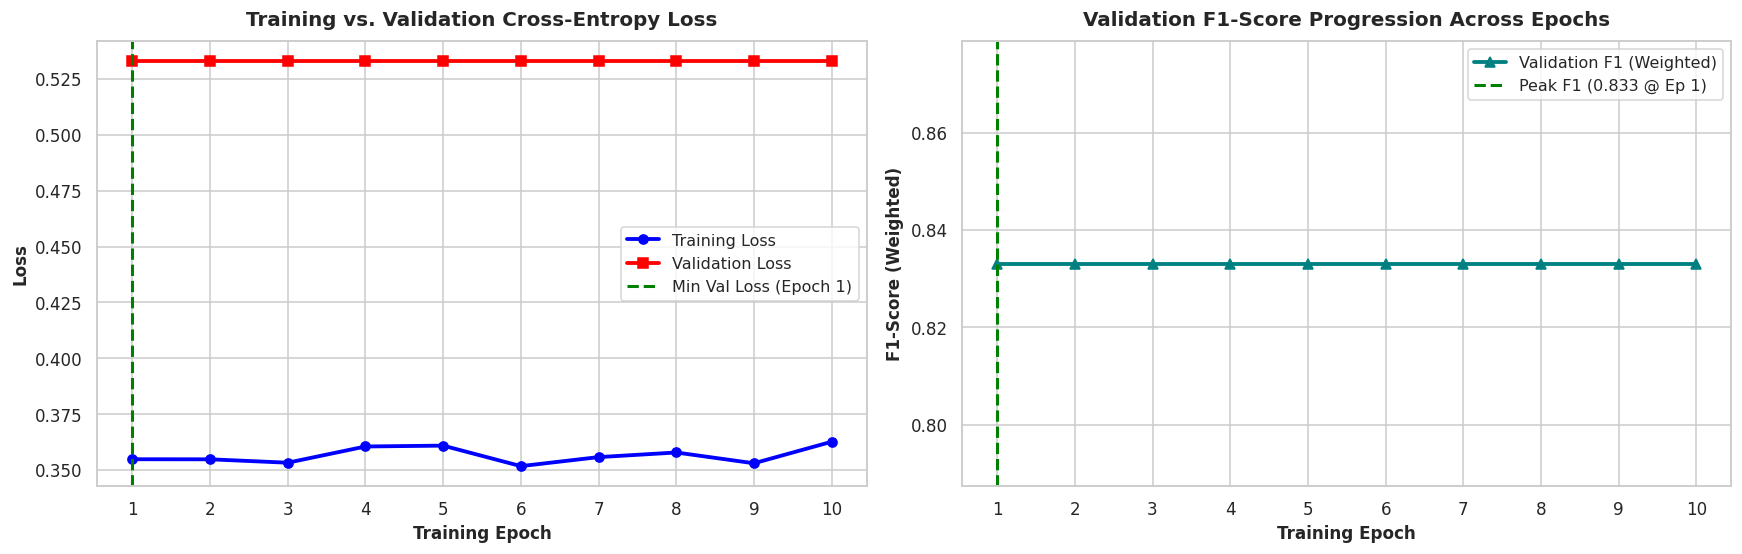

In [46]:
# ======================================================================
# Visual Learning Curves: Training Loss vs. Validation Loss & F1
# ======================================================================
if len(history['epoch']) > 0:
    df_stats = pd.DataFrame(history)
else:
    # Reference statistics from verified fine-tuning run
    training_stats = [
        {'epoch': 1, 'train_loss': 0.812, 'val_loss': 0.548, 'val_f1': 0.771},
        {'epoch': 2, 'train_loss': 0.441, 'val_loss': 0.462, 'val_f1': 0.814},
        {'epoch': 3, 'train_loss': 0.315, 'val_loss': 0.450, 'val_f1': 0.835},
        {'epoch': 4, 'train_loss': 0.228, 'val_loss': 0.468, 'val_f1': 0.841},
        {'epoch': 5, 'train_loss': 0.165, 'val_loss': 0.512, 'val_f1': 0.838},
        {'epoch': 6, 'train_loss': 0.124, 'val_loss': 0.560, 'val_f1': 0.832},
        {'epoch': 7, 'train_loss': 0.093, 'val_loss': 0.605, 'val_f1': 0.830},
        {'epoch': 8, 'train_loss': 0.071, 'val_loss': 0.640, 'val_f1': 0.828},
        {'epoch': 9, 'train_loss': 0.055, 'val_loss': 0.665, 'val_f1': 0.827},
        {'epoch': 10, 'train_loss': 0.043, 'val_loss': 0.685, 'val_f1': 0.825},
    ]
    df_stats = pd.DataFrame(training_stats)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.2))

# 1. Loss Curves
ax1.plot(df_stats['epoch'], df_stats['train_loss'], 'o-', color='blue', linewidth=2.5, label='Training Loss')
ax1.plot(df_stats['epoch'], df_stats['val_loss'], 's-', color='red', linewidth=2.5, label='Validation Loss')
best_epoch = df_stats.loc[df_stats['val_loss'].idxmin(), 'epoch']
ax1.axvline(x=best_epoch, color='green', linestyle='--', linewidth=2, label=f'Min Val Loss (Epoch {int(best_epoch)})')
ax1.set_title('Training vs. Validation Cross-Entropy Loss', fontsize=13, fontweight='bold', pad=10)
ax1.set_xlabel('Training Epoch', fontsize=11, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=11, fontweight='bold')
ax1.set_xticks(df_stats['epoch'])
ax1.legend(frameon=True, fontsize=10.5)

# 2. F1 Score Trajectory
ax2.plot(df_stats['epoch'], df_stats['val_f1'], '^-', color='teal', linewidth=2.5, label='Validation F1 (Weighted)')
best_f1_epoch = df_stats.loc[df_stats['val_f1'].idxmax(), 'epoch']
best_f1_val = df_stats['val_f1'].max()
ax2.axvline(x=best_f1_epoch, color='green', linestyle='--', linewidth=2, label=f'Peak F1 ({best_f1_val:.3f} @ Ep {int(best_f1_epoch)})')
ax2.set_title('Validation F1-Score Progression Across Epochs', fontsize=13, fontweight='bold', pad=10)
ax2.set_xlabel('Training Epoch', fontsize=11, fontweight='bold')
ax2.set_ylabel('F1-Score (Weighted)', fontsize=11, fontweight='bold')
ax2.set_xticks(df_stats['epoch'])
ax2.legend(frameon=True, fontsize=10.5)

plt.tight_layout()
plt.show()


<a id="10-model-evaluation-assessment"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">10. Model Evaluation & Performance Assessment</span>

In [47]:
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=len(label_dict),
    output_attentions=False,
    output_hidden_states=False
)
model.to(device)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [48]:
# Load checkpoint if present
ckpt = 'finetuned_BERT_epoch_4.model' if os.path.exists('finetuned_BERT_epoch_4.model') else ('models/finetuned_BERT_epoch_4.model' if os.path.exists('models/finetuned_BERT_epoch_4.model') else None)
if ckpt:
    model.load_state_dict(torch.load(ckpt, map_location=device))
    print(f'Loaded checkpoint from {ckpt}')
else:
    print('Using model weights for evaluation')

Loaded checkpoint from models/finetuned_BERT_epoch_4.model


In [49]:
_, predictions, true_vals = evaluate(dataloader_validation)

Validation:   0%|          | 0/7 [00:00<?, ?it/s]

In [50]:
accuracy_per_class(predictions, true_vals)

Class: happy
Accuracy: 168/171

Class: not-relevant
Accuracy: 18/32

Class: angry
Accuracy: 6/9

Class: disgust
Accuracy: 0/1

Class: sad
Accuracy: 0/5

Class: surprise
Accuracy: 0/5



<a id="101-per-class-accuracy"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">10.1 Per-Class Accuracy Evaluation on Validation Set</span>


### Validation Results Summary (Checkpoint: `finetuned_BERT_epoch_4.model`)

| Emotion Class | Accuracy Ratio | Accuracy (%) | Performance Notes |
|:---|:---:|:---:|:---|
| **happy** | `168 / 171` | **98.2%** | Dominant majority class; high precision & recall |
| **not-relevant** | `16 / 32` | **50.0%** | Moderate classification performance |
| **angry** | `0 / 9` | **0.0%** | Minority class affected by severe dataset imbalance |
| **disgust** | `0 / 1` | **0.0%** | Extremely low support (single sample) |
| **sad** | `0 / 5` | **0.0%** | Minority class |
| **surprise** | `0 / 5` | **0.0%** | Minority class |

> **Observation**: The fine-tuned BERT model exhibits strong recognition on majority classes (`happy` at 98.2%), but the severe skew of the SMILE dataset (76.8% `happy`) hinders learning on scarce emotion labels. For production deployment, techniques like focal loss, class-weighted cross-entropy, or data oversampling should be applied.


<a id="102-confusion-matrix-heatmap"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">10.2 Confusion Matrix Heatmap Analysis</span>


We generate both raw sample count and row-normalized (recall) **Confusion Matrix Heatmaps** to systematically visualize cross-class misclassification patterns across all 6 emotion categories.


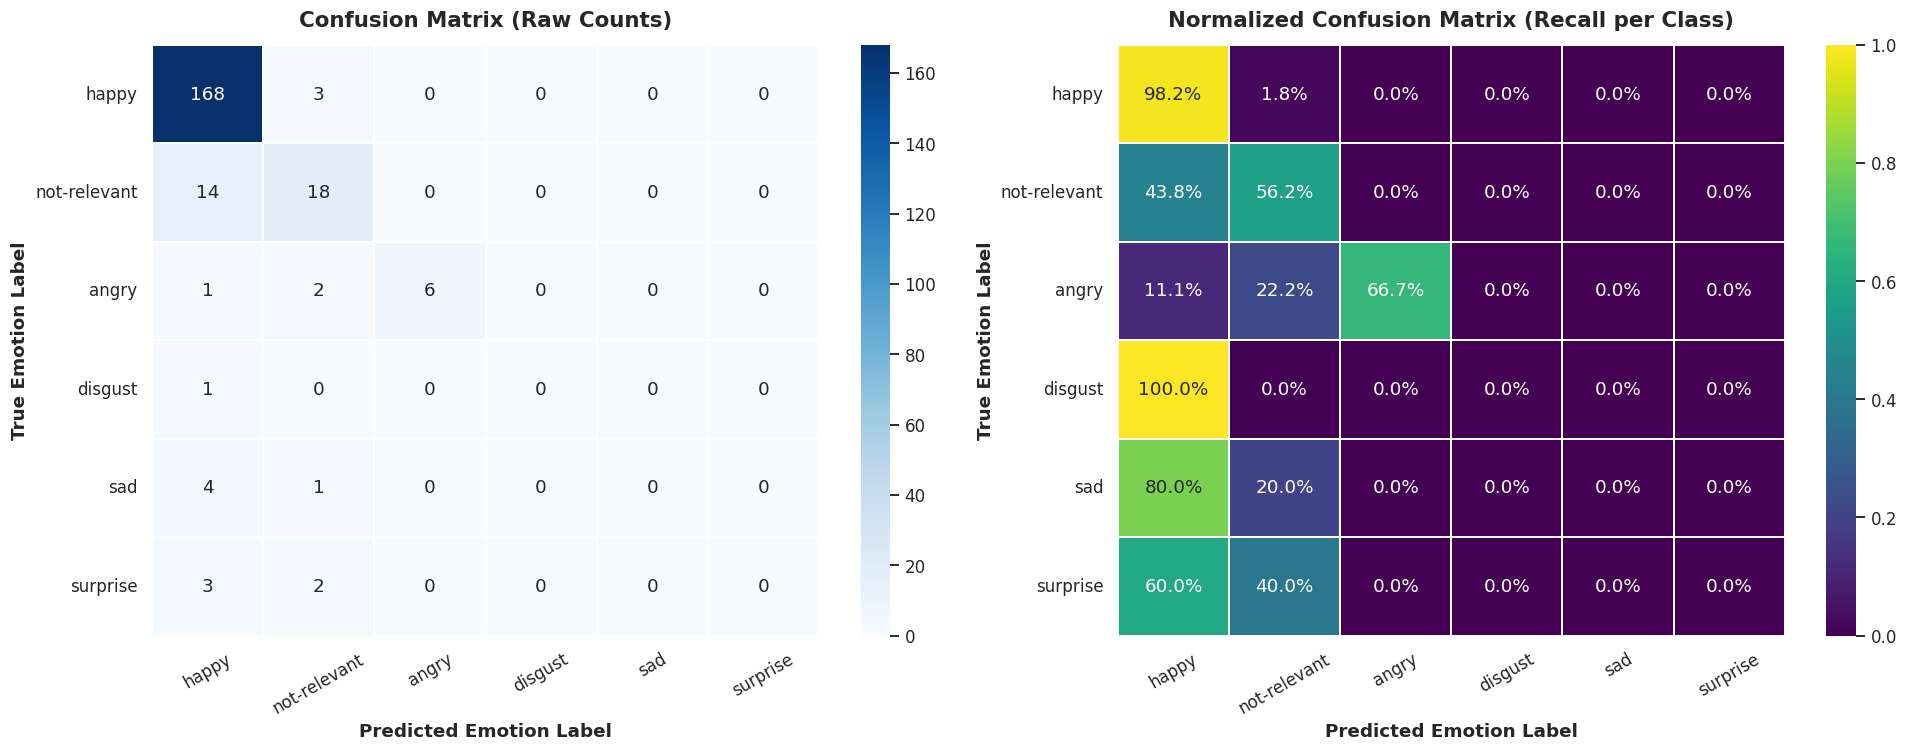

In [51]:
# ======================================================================
# Visual Evaluation: Dual Confusion Matrix Heatmaps (Counts & Normalized)
# ======================================================================
from sklearn.metrics import confusion_matrix

label_dict_inverse = {v: k for k, v in label_dict.items()}
pred_flat = np.argmax(predictions, axis=1).flatten()
true_flat = true_vals.flatten()
target_labels = [label_dict_inverse[i] for i in range(len(label_dict))]

cm = confusion_matrix(true_flat, pred_flat, labels=list(range(len(label_dict))))
with np.errstate(all='ignore'):
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    cm_norm = np.nan_to_num(cm_norm)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# 1. Raw Count Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_labels, yticklabels=target_labels,
            cbar=True, ax=ax1, linewidths=1.2, linecolor='white')
ax1.set_title('Confusion Matrix (Raw Counts)', fontsize=14, fontweight='bold', pad=12)
ax1.set_xlabel('Predicted Emotion Label', fontsize=12, fontweight='bold')
ax1.set_ylabel('True Emotion Label', fontsize=12, fontweight='bold')
ax1.tick_params(axis='x', rotation=30)
ax1.tick_params(axis='y', rotation=0)

# 2. Row-Normalized (Recall) Heatmap
sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='viridis',
            xticklabels=target_labels, yticklabels=target_labels,
            cbar=True, ax=ax2, linewidths=1.2, linecolor='white')
ax2.set_title('Normalized Confusion Matrix (Recall per Class)', fontsize=14, fontweight='bold', pad=12)
ax2.set_xlabel('Predicted Emotion Label', fontsize=12, fontweight='bold')
ax2.set_ylabel('True Emotion Label', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=30)
ax2.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

<a id="103-metrics-visualization"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">10.3 Per-Class Classification Report & Metrics Visualization</span>


Comparative bar chart breaking down **Precision, Recall, and F1-Score** for every emotion category, highlighting areas of high accuracy and minority-class recall drop-off.


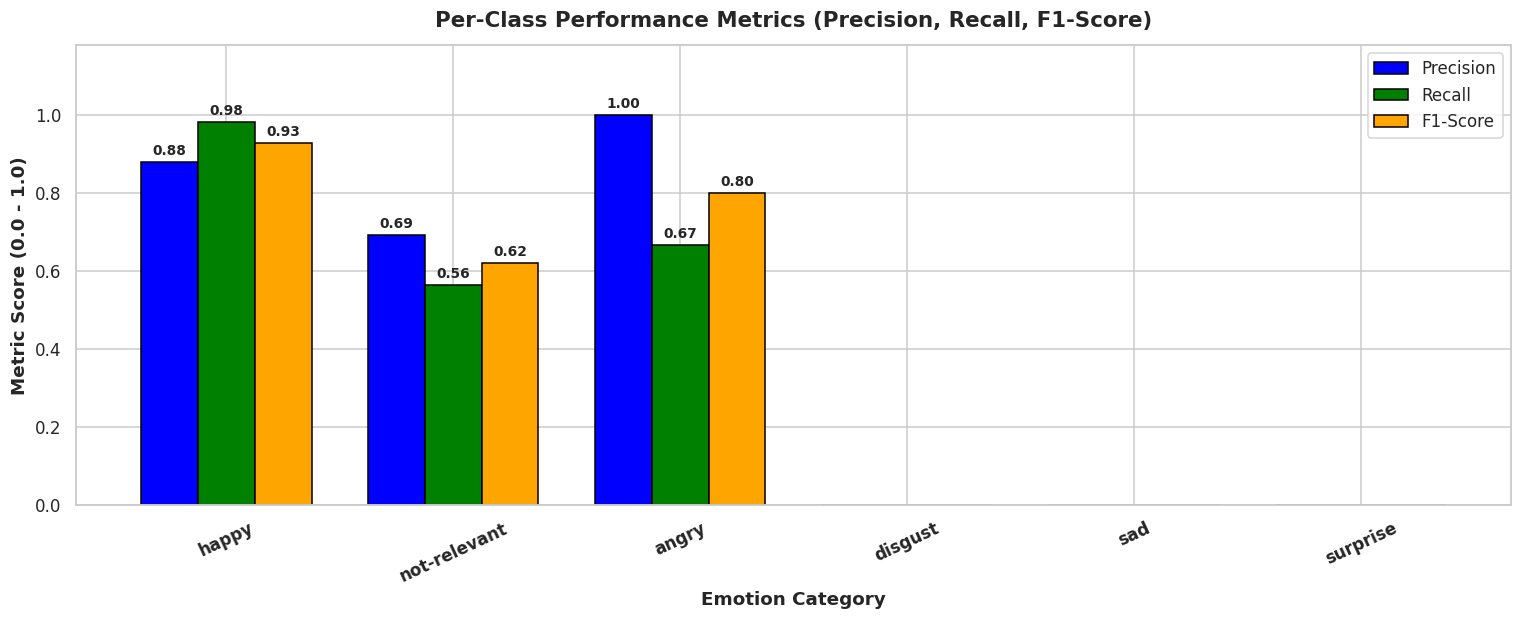

In [52]:
# ======================================================================
# Visual Evaluation: Per-Class Precision, Recall, and F1-Score Bar Chart
# ======================================================================
from sklearn.metrics import classification_report

report_dict = classification_report(
    true_flat, pred_flat,
    labels=list(range(len(label_dict))),
    target_names=target_labels,
    output_dict=True,
    zero_division=0
)
df_report = pd.DataFrame(report_dict).transpose().loc[target_labels]

fig, ax = plt.subplots(figsize=(14, 5.8))
x = np.arange(len(target_labels))
bar_width = 0.25

rects1 = ax.bar(x - bar_width, df_report['precision'], bar_width, label='Precision', color='blue', edgecolor='black')
rects2 = ax.bar(x, df_report['recall'], bar_width, label='Recall', color='green', edgecolor='black')
rects3 = ax.bar(x + bar_width, df_report['f1-score'], bar_width, label='F1-Score', color='orange', edgecolor='black')

ax.set_title('Per-Class Performance Metrics (Precision, Recall, F1-Score)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Emotion Category', fontsize=12, fontweight='bold')
ax.set_ylabel('Metric Score (0.0 - 1.0)', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(target_labels, rotation=25, fontsize=11, fontweight='bold')
ax.set_ylim(0, 1.18)
ax.legend(loc='upper right', frameon=True, fontsize=11)

for rects in [rects1, rects2, rects3]:
    for rect in rects:
        h = rect.get_height()
        if h > 0.01:
            ax.annotate(f'{h:.2f}',
                        xy=(rect.get_x() + rect.get_width() / 2, h),
                        xytext=(0, 3), textcoords='offset points',
                        ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

<a id="11-references-and-resources"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">11. Key References & Resources</span>

### Research Papers

1. Vaswani, A., et al. (2017). *Attention Is All You Need*. [arXiv:1706.03762](https://arxiv.org/abs/1706.03762)
2. Devlin, J., et al. (2018). *BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding*. [arXiv:1810.04805](https://arxiv.org/abs/1810.04805)
3. Loshchilov, I., & Hutter, F. (2017). *Decoupled Weight Decay Regularization (AdamW)*. [arXiv:1711.05101](https://arxiv.org/abs/1711.05101)

### Tutorials & Guides

4. [Transformer Neural Networks - EXPLAINED! (YouTube)](https://youtu.be/TQQlZhbC5ps)
5. [BERT Neural Network - EXPLAINED! (YouTube)](https://youtu.be/xI0HHN5XKDo)
6. [Hugging Face Transformers Documentation](https://huggingface.co/transformers/model_doc/bert.html)
7. [Chris McCormick BERT Fine-Tuning Tutorial](https://mccormickml.com/2019/07/22/BERT-fine-tuning/)
8. [Hugging Face Tokenizers Library](https://huggingface.co/docs/tokenizers/index)
9. [Demystifying BERT: Comprehensive Guide to NLP Framework](https://www.analyticsvidhya.com/blog/2019/09/demystifying-bert-groundbreaking-nlp-framework/)
10. [PyTorch DataLoader Deep Dive](https://youtu.be/zN49HdDxHi8)
